# **K-means on images**

Use the following images:
 - [image1.jpeg](https://drive.google.com/file/d/1ehjQbNbSLTPOdnzZf5mtcokH-Irb9Hsq/view?usp=sharing)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
#Image segmentation from video using OpenCV and K-means clustering
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

(128, 128, 3) (128, 128, 3)


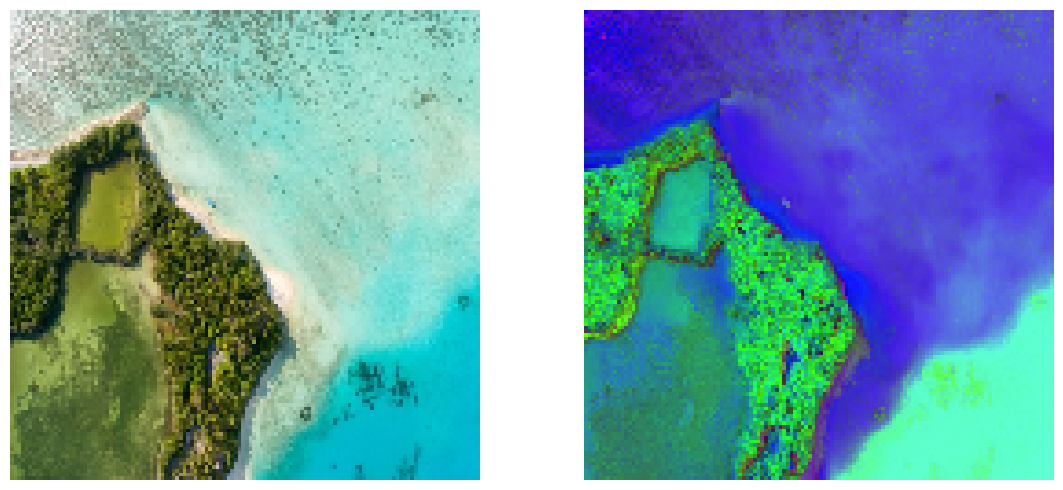

In [48]:
original_image = cv2.imread('/content/image1.jpeg')

# Resize to a feasible size to avoid extensive computation
original_image = cv2.resize(original_image, (128,128))

# Convert from BGR Color Space to HSV
img_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(original_image, cv2.COLOR_BGR2HSV)

_, axes = plt.subplots (1, 2, figsize = (12,5))
axes[0].imshow( img_rgb ), axes[0].set_axis_off() #RGB
axes[1].imshow( img_hsv ), axes[1].set_axis_off() #HSV
plt.tight_layout()

print(img_rgb.shape, img_hsv.shape)


In [49]:
# Vectorize to compute kmeans
vectorized_rgb = img_rgb.copy().reshape( 128*128, 3 ) #numero de canales 3
vectorized_rgb = np.float32(vectorized_rgb)

vectorized_hsv = img_rgb.copy().reshape( 128*128, 3 ) #numero de canales 3
vectorized_hsv = np.float32(vectorized_hsv)

# Check both vector sizes
print(vectorized_rgb.shape, vectorized_hsv.shape)

(16384, 3) (16384, 3)


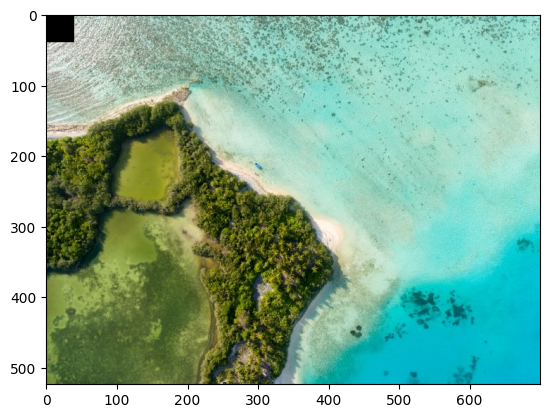

In [44]:
#img_ap = img_rgb.copy() #diferencia entre img_rgb y img_rgb.copy()

img_rgb[0:40, 0:40, :] = 0

plt.imshow(img_ap)

## **RGB image**

In [50]:
# Train kmeans
n = 3
kmeans = KMeans(n_clusters = n, random_state = 0, max_iter = 100).fit( vectorized_rgb )

In [51]:
# Predict to segment regions
clustered_rgb = kmeans.predict( vectorized_rgb )
clustered_rgb = clustered_rgb.reshape( img_rgb.shape[:2] ) #devuelve una tupla y reescala arreglo a ese tamano

print(vectorized_rgb.shape, img_rgb.shape, clustered_rgb.shape)

(16384, 3) (128, 128, 3) (128, 128)


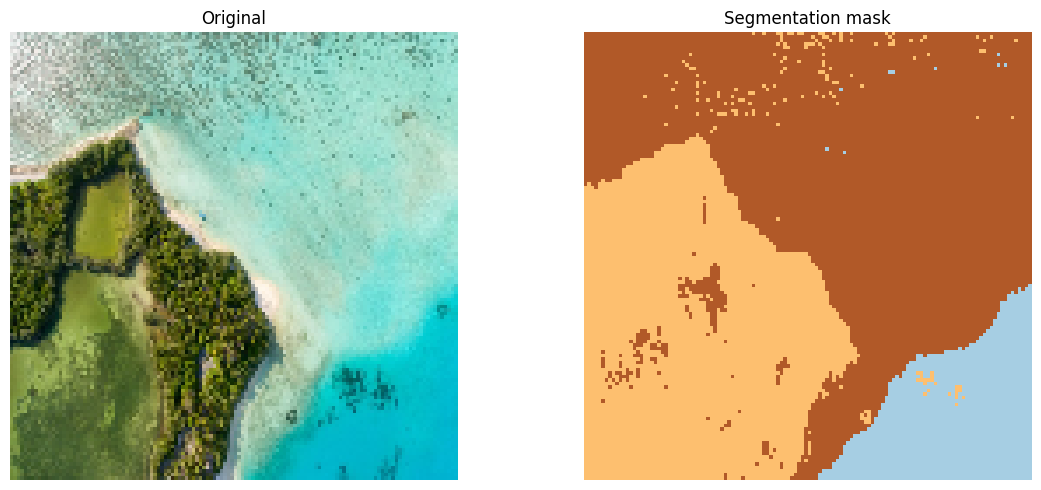

In [52]:
# Plot original and segmentation masks
_, axes = plt.subplots (1, 2, figsize = (12,5))
axes[0].imshow( img_rgb ), axes[0].set_axis_off(), axes[0].set_title("Original")
axes[1].imshow( clustered_rgb, cmap = 'Paired' ), axes[1].set_axis_off(), axes[1].set_title("Segmentation mask")
plt.tight_layout()

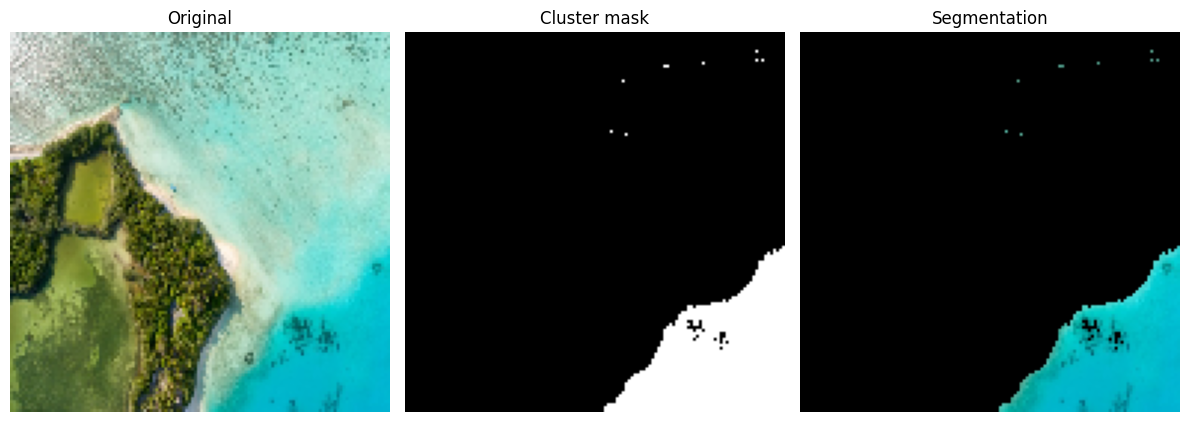

In [56]:
# Mask only the cluster number 0 (turn the rest of pixels into black)
cluster = 0 #1

cluster_mask = np.array ( clustered_rgb == cluster , dtype = np.uint8)

masked_image = np.copy(img_rgb)
masked_image = cv2.bitwise_and(masked_image, masked_image, mask = cluster_mask ) #aplica la mascara segun el criterio (valores de pix en este caso)

_, axes = plt.subplots (1, 3, figsize = (12,5))
axes[0].imshow( img_rgb ), axes[0].set_axis_off(), axes[0].set_title("Original")
axes[1].imshow( cluster_mask , cmap="gray"), axes[1].set_axis_off(), axes[1].set_title("Cluster mask")
axes[2].imshow( masked_image ), axes[2].set_axis_off(), axes[2].set_title("Segmentation")
plt.tight_layout()

## **HSV image**

In [57]:
# Train kmeans
n = 3
kmeans = KMeans(n_clusters = n, random_state=0).fit( vectorized_hsv )

In [58]:
# Predict to segment regions
clustered_hsv = kmeans.predict( vectorized_hsv )
clustered_hsv = clustered_hsv.reshape( img_hsv.shape[:2] )

print(vectorized_hsv.shape, img_rgb.shape, clustered_hsv.shape)

(16384, 3) (128, 128, 3) (128, 128)


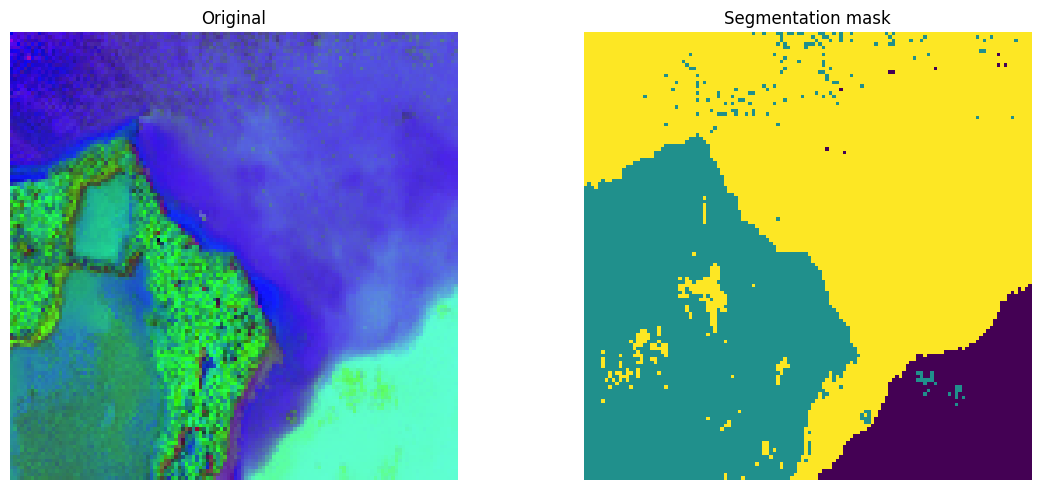

In [59]:
# Plot original and segmentation masks
_, axes = plt.subplots (1, 2, figsize = (12,5))
axes[0].imshow( img_hsv ), axes[0].set_axis_off(), axes[0].set_title("Original")
axes[1].imshow( clustered_hsv ), axes[1].set_axis_off(), axes[1].set_title("Segmentation mask")
plt.tight_layout()

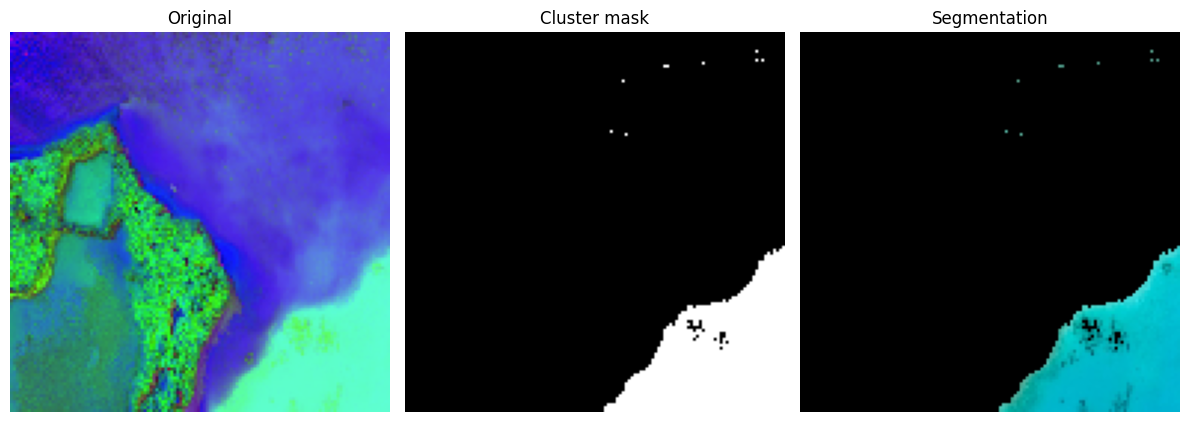

In [60]:
# Mask only the cluster number 0 (turn the rest of pixels into black)
cluster = 0

cluster_mask = np.array ( clustered_hsv == cluster , dtype = np.uint8)

masked_image = np.copy(img_rgb)
masked_image = cv2.bitwise_and(masked_image, masked_image, mask = cluster_mask )

_, axes = plt.subplots (1, 3, figsize = (12,5))
axes[0].imshow( img_hsv ), axes[0].set_axis_off(), axes[0].set_title("Original")
axes[1].imshow( cluster_mask , cmap="gray"), axes[1].set_axis_off(), axes[1].set_title("Cluster mask")
axes[2].imshow( masked_image ), axes[2].set_axis_off(), axes[2].set_title("Segmentation")
plt.tight_layout()

## **Comparison**

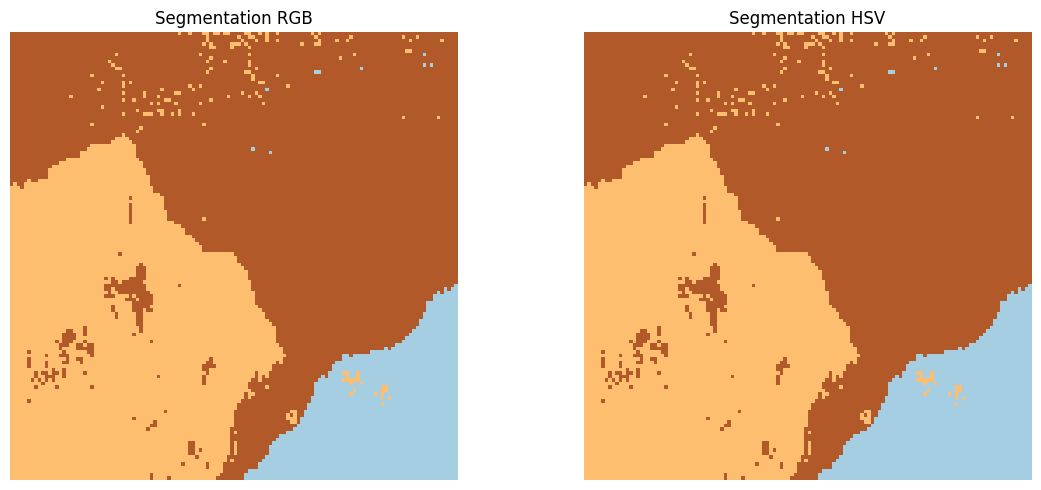

In [61]:
_, axes = plt.subplots (1, 2, figsize = (12,5))
axes[0].imshow(clustered_rgb, cmap="Paired"), axes[0].set_axis_off(), axes[0].set_title("Segmentation RGB")
axes[1].imshow(clustered_hsv, cmap="Paired"), axes[1].set_axis_off(), axes[1].set_title("Segmentation HSV")
plt.tight_layout()

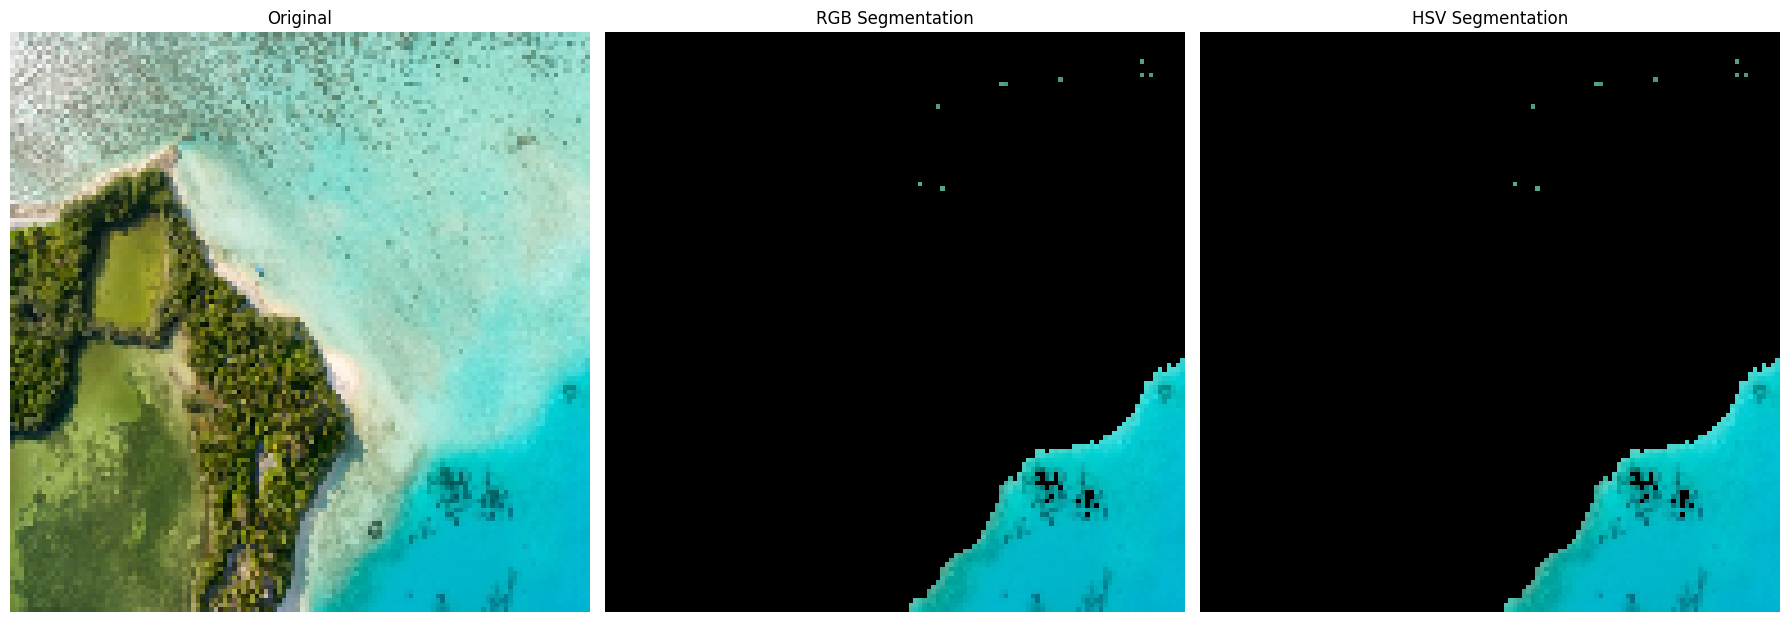

In [64]:
# Mask clusters (turn the rest of pixels into black)
cluster = 0
cluster_mask_rgb = np.array ( clustered_rgb == cluster , dtype = np.uint8)

cluster = 0
cluster_mask_hsv = np.array ( clustered_hsv == cluster , dtype = np.uint8)

masked_rgb = np.copy(img_rgb)
masked_rgb = cv2.bitwise_and(masked_rgb, masked_rgb, mask = cluster_mask )

masked_hsv = np.copy(img_rgb)
masked_hsv = cv2.bitwise_and(masked_hsv, masked_hsv, mask = cluster_mask )

_, axes = plt.subplots (1, 3, figsize = (18,8))
axes[0].imshow(img_rgb), axes[0].set_axis_off(), axes[0].set_title("Original")
axes[1].imshow(masked_rgb), axes[1].set_axis_off(), axes[1].set_title("RGB Segmentation")
axes[2].imshow(masked_hsv), axes[2].set_axis_off(), axes[2].set_title("HSV Segmentation")
plt.tight_layout()

# **Elbow and Silhouette**

Perform an analysis based on elbow and silhouette to determine the best number of clusters

# **In random images**


Repeat the segmentation with the following images:
 - [fr1.png](https://drive.google.com/file/d/18OR0DEx-rXeVBeqgbZqhzXXyOQhMyefb/view?usp=sharing)
 - [fr2.png](https://drive.google.com/file/d/1ehjQbNbSLTPOdnzZf5mtcokH-Irb9Hsq/view?usp=sharing)
 - [fr3.jpeg](https://drive.google.com/file/d/1ehjQbNbSLTPOdnzZf5mtcokH-Irb9Hsq/view?usp=sharing)
 - [fr4.jpeg](https://drive.google.com/file/d/1ehjQbNbSLTPOdnzZf5mtcokH-Irb9Hsq/view?usp=sharing)
